In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, f_oneway, chi2_contingency
from scipy import stats

In [2]:
df = pd.read_csv('penguins.csv')
df_clean = df.dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
# ------- PARTE A -------- Observacion inicial
# 1. ¿Cuántas filas y columnas tiene el dataset?
forma = df.shape
print(f"Hay {df.shape[0]} filas y {df.shape[1]} columnas.")

Hay 344 filas y 7 columnas.


In [4]:
# 2.¿Qué variables son numéricas y cuáles categóricas? species, island y sex son las variables categóricas. Bill_length, bill_depth, flipper_length y body_mass son numéricas
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [5]:
# 3.¿Cuántos valores faltantes hay por columna?
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
# 4. ¿Existen filas duplicadas? No
df.duplicated().sum()

np.int64(0)

In [7]:
# 5. ¿Qué variables tienen baja cardinalidad? Las variables categóricas
df.nunique()

species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    2
dtype: int64

In [8]:
# --- PARTE B: Descripción ---
# 6. Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
print("\n--- PARTE B ---")
print("\n6) Resumen variables numéricas:")
display(df.describe().T[['mean', '50%', 'std']].rename(columns={'50%': 'mediana'}))


--- PARTE B ---

6) Resumen variables numéricas:


,mean,mediana,std
bill_length_mm,43.921930,44.45,5.459584
bill_depth_mm,17.151170,17.30,1.974793
flipper_length_mm,200.915205,197.00,14.061714
body_mass_g,4201.754386,4050.00,801.954536


In [9]:
# describe calcula las estadisticas de las cantidades numericas. T transpone la tabla. [[]] selecciona las columnas
display(df.describe().T[['mean', '50%', 'std']].rename(columns={'50%': 'mediana'}))

,mean,mediana,std
bill_length_mm,43.921930,44.45,5.459584
bill_depth_mm,17.151170,17.30,1.974793
flipper_length_mm,200.915205,197.00,14.061714
body_mass_g,4201.754386,4050.00,801.954536


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [11]:
# Rango Intercuartílico (IQR) para numéricas
numeric_cols = df.select_dtypes(include=['float64']).columns
iqr = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
print("\nRango Intercuartílico (IQR):\n", iqr)


Rango Intercuartílico (IQR):
 bill_length_mm          9.275
bill_depth_mm           3.100
flipper_length_mm      23.000
body_mass_g          1200.000
dtype: float64


In [12]:
df.select_dtypes(include = [np.number]).columns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

In [14]:
# 7. Para cada variable categórica, reporte conteos y porcentajes
categorical_cols = df.select_dtypes(include = ['object']).columns
df[categorical_cols].describe().T

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True, dropna=False) * 100)


--- species ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: proportion, dtype: float64

--- island ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
island
Biscoe       48.837209
Dream        36.046512
Torgersen    15.116279
Name: proportion, dtype: float64

--- sex ---
sex
MALE      168
FEMALE    165
NaN        11
Name: count, dtype: int64
sex
MALE      48.837209
FEMALE    47.965116
NaN        3.197674
Name: proportion, dtype: float64


In [45]:
# 8. Construya tablas cruzadas para pares de variables categóricas relevantes
pd.crosstab(df['species'], df['island'])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [16]:
pd.crosstab(df['island'], df['sex'])

sex,FEMALE,MALE
island,,
Biscoe,80,83
Dream,61,62
Torgersen,24,23


In [47]:
# Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.
print("\nCorrelación Pearson:\n", df[numeric_cols].corr(method='person'))


Correlación Pearson:
                    bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  


In [49]:
print("\nCorrelación Spearman:\n", df[numeric_cols].corr(method='spearman'))


Correlación Spearman:
                    bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.221749           0.672772   
bill_depth_mm           -0.221749       1.000000          -0.523267   
flipper_length_mm        0.672772      -0.523267           1.000000   
body_mass_g              0.583800      -0.432372           0.839974   

                   body_mass_g  
bill_length_mm        0.583800  
bill_depth_mm        -0.432372  
flipper_length_mm     0.839974  
body_mass_g           1.000000  


Text(0.5, 1.0, 'Conteo de especie por isla')

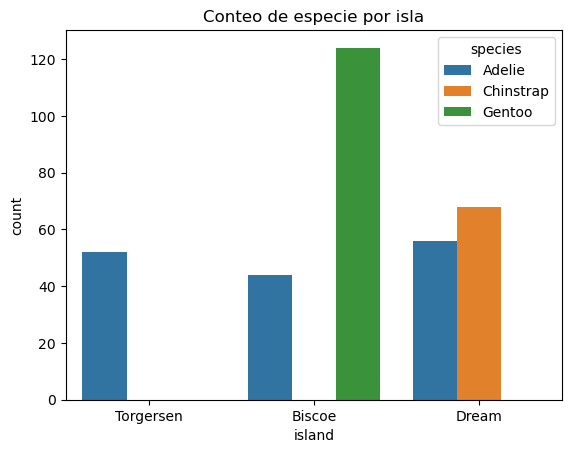

In [22]:
# 10. Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
sns.countplot(data=df, x='island', hue='species')
plt.title('Conteo de especie por isla')

In [35]:
numeric_cols

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

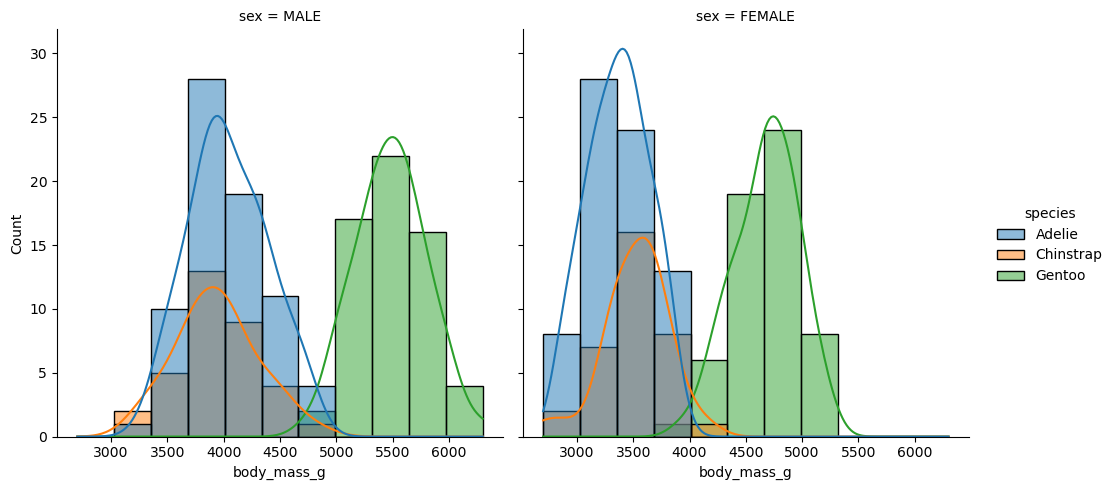

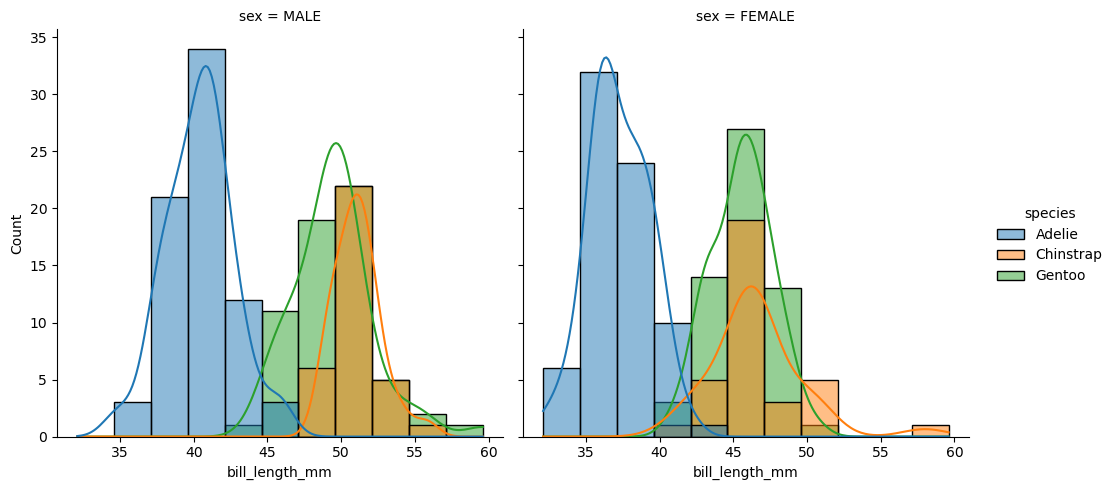

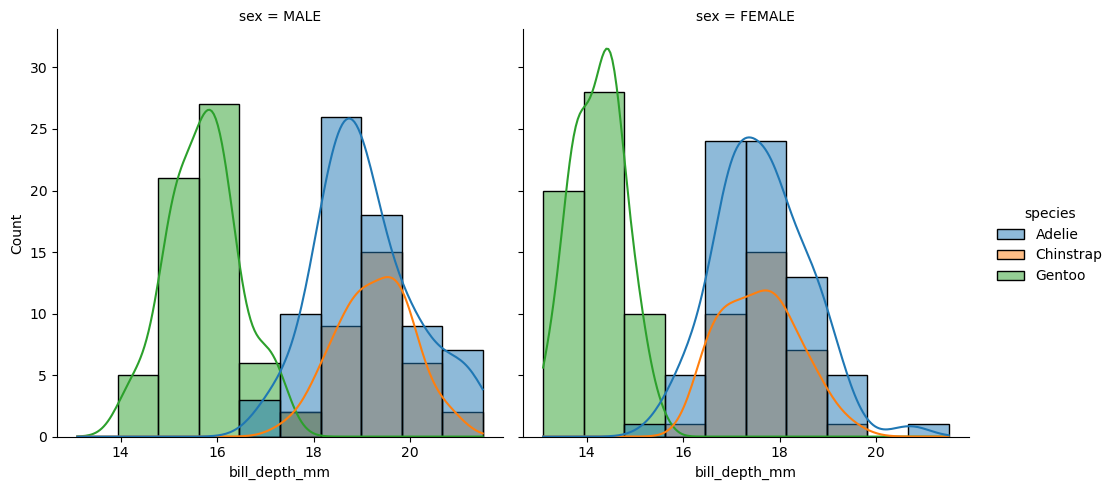

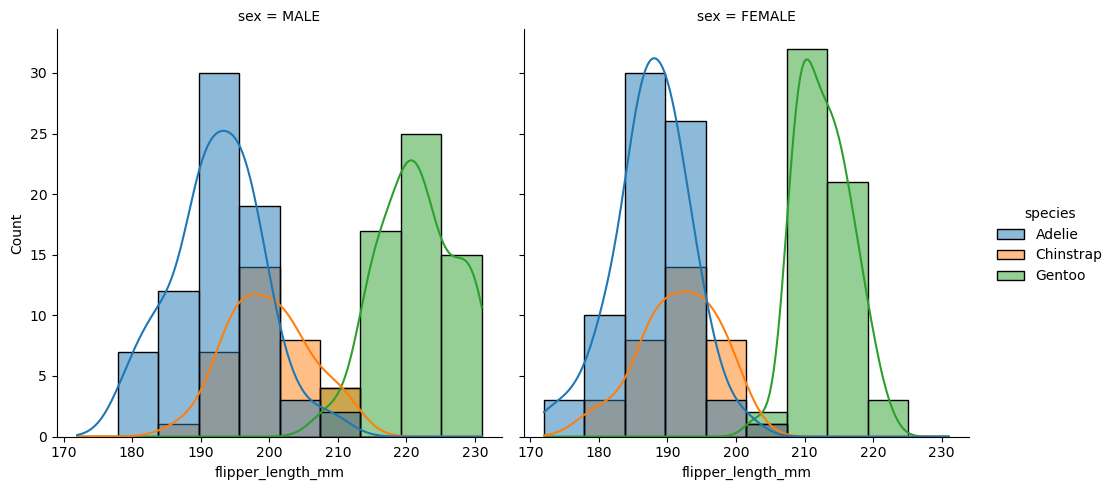

In [44]:
# # 11. Genere histogramas para variables numéricas y describa su forma.
# Un gráfico por cada variable (Seaborn genera las columnas por sexo automáticamente)
sns.displot(data=df.dropna(subset=['sex']), x='body_mass_g', hue='species', col='sex', kind='hist', kde=True)
sns.displot(data=df.dropna(subset=['sex']), x='bill_length_mm', hue='species', col='sex', kind='hist', kde=True)
sns.displot(data=df.dropna(subset=['sex']), x='bill_depth_mm', hue='species', col='sex', kind='hist', kde=True)
sns.displot(data=df.dropna(subset=['sex']), x='flipper_length_mm', hue='species', col='sex', kind='hist', kde=True)
# Comentario: de estos histogramas, el diformismo sexual es claro

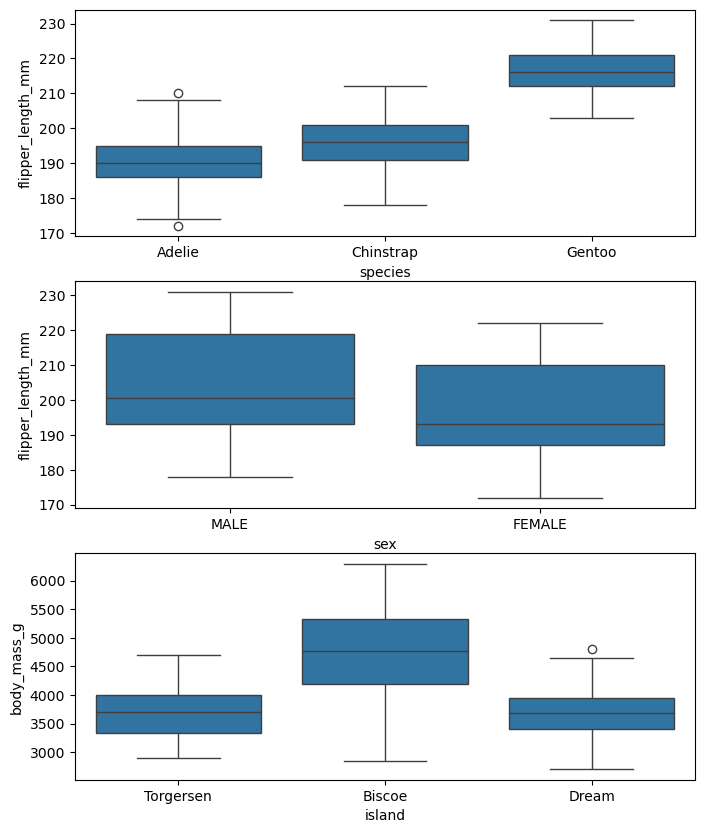

In [49]:
# 12. Genere boxplots de una variable numérica por categoría.
fig, axes = plt.subplots(3, 1, figsize=(8, 10))
sns.boxplot(data=df, x='species', y='flipper_length_mm', ax=axes[0])
sns.boxplot(data=df, x='sex', y='flipper_length_mm', ax=axes[1])
sns.boxplot(data=df, x='island', y='body_mass_g', ax=axes[2])
plt.show()

<Axes: xlabel='bill_depth_mm', ylabel='bill_length_mm'>

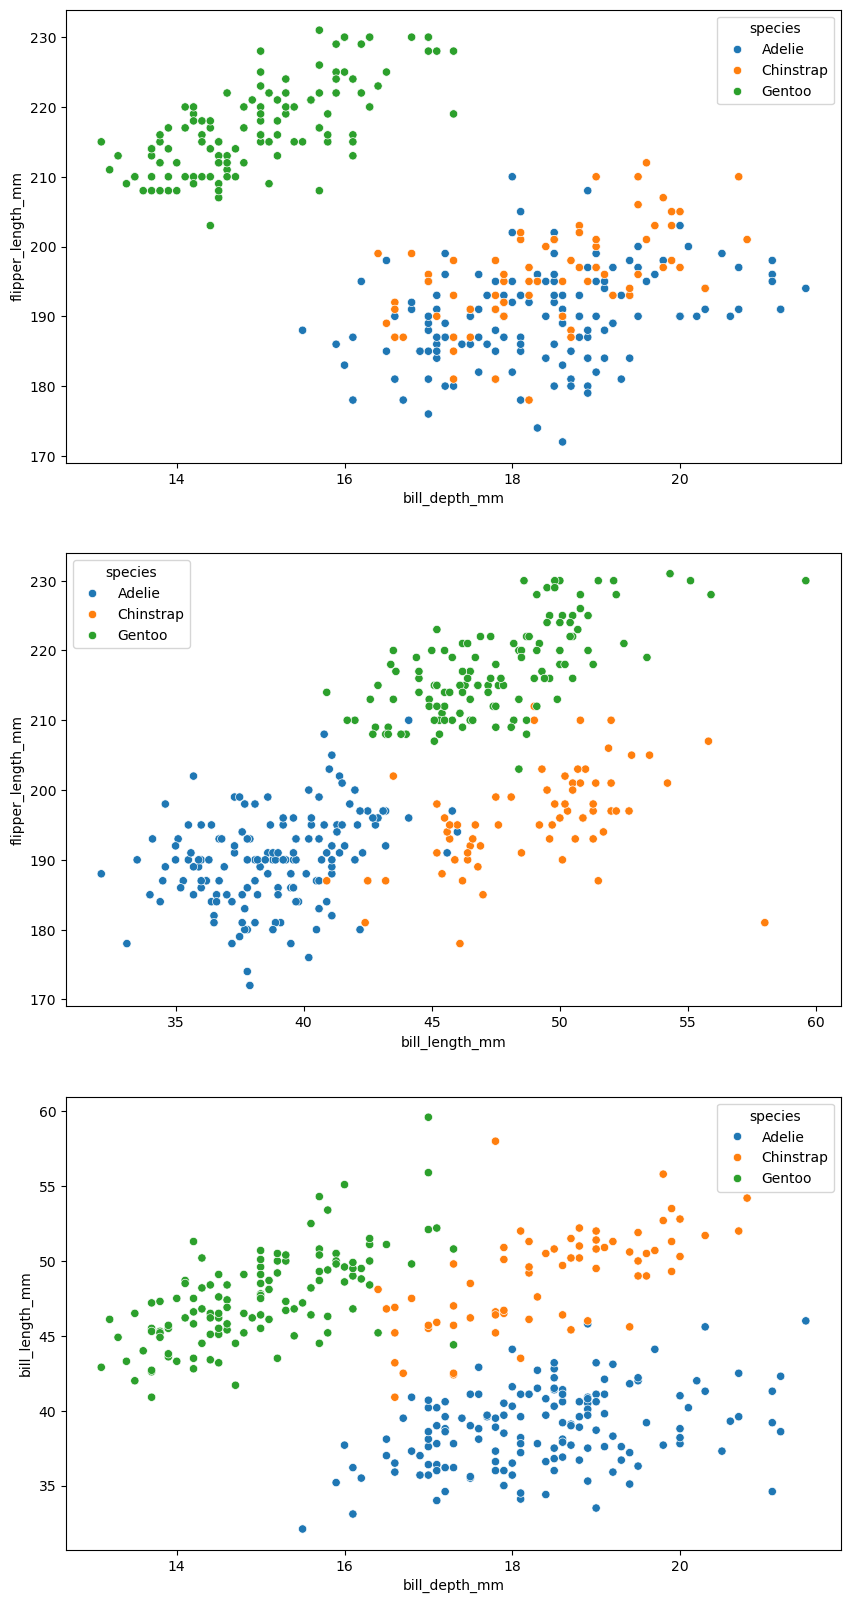

In [25]:
# 13. Genere un scatter entre dos variables numéricas y coloree por una categoría
fig, axes = plt.subplots(3, 1, figsize=(10, 20))
sns.scatterplot(data=df, x='bill_depth_mm', y='flipper_length_mm', hue='species', ax = axes[0])
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species', ax = axes[1])
sns.scatterplot(data=df, x='bill_depth_mm', y='bill_length_mm', hue='species', ax = axes[2])

## Comentario: El único caso en el que no parece disernirse la especie según una variable numérica, es para la longitud de la aleta, más concretamente entre Adelie y Chinstrap.

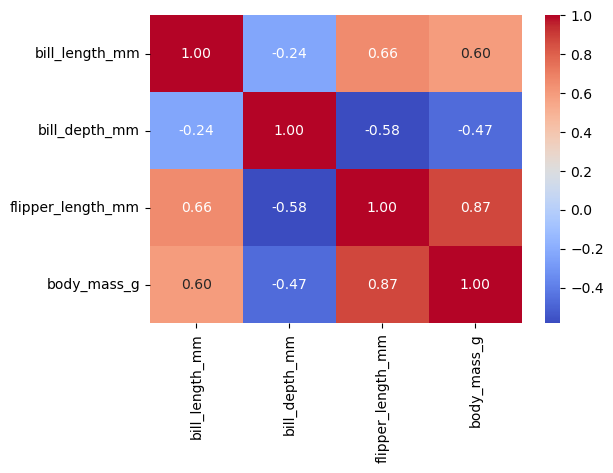

In [34]:
# 14. Genere un heatmap de correlación
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
Parte D — Hipótesis (sin causalidad) 15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos. 

1. bill_length_mm y bill_depth_mm no están asociados.
2. No hay correlación entre la especie y la isla que habita.
3. Las longitudes medias de las aletas de los pinguinos Chinstrap y Gentoo no son significativamente distintas.

Parte E — Pruebas estadísticas 16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado). 17) Reporte estadístico y p-valor. 18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

In [7]:
# 15. Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos. Usando funciones ya hechas.
# H1: body_mass_g y flipper_length_mm están correlacionados (Pearson)
r, p_pearson = pearsonr(df_clean['bill_depth_mm'], df_clean['bill_length_mm'])
print(f"H1 (Pearson) - r: {r:.2f}, p-valor: {p_pearson:.2e}. {'Se apoya' if p_pearson < 0.05 else 'Se rechaza'}")

# H2: bill_length_mm difiere por species (ANOVA)
anova = f_oneway(*[g['bill_depth_mm'].values for n, g in df_clean.groupby('sex')])
print(f"H2 (ANOVA) - F: {anova.statistic:.2f}, p-valor: {anova.pvalue:.2e}. {'Se apoya' if anova.pvalue < 0.05 else 'Se rechaza'}")

# H3: species se asocia con island (Chi-cuadrado)
chi2, p_chi, _, _ = chi2_contingency(pd.crosstab(df['sex'], df['island']))
print(f"H3 (Chi2) - Chi2: {chi2:.2f}, p-valor: {p_chi:.2e}. {'Se apoya' if p_chi < 0.05 else 'Se rechaza'}")

H1 (Pearson) - r: -0.23, p-valor: 2.53e-05. Se apoya
H2 (ANOVA) - F: 53.39, p-valor: 2.07e-12. Se apoya
H3 (Chi2) - Chi2: 0.06, p-valor: 9.72e-01. Se rechaza


In [27]:
### En todos se usa una confianza del 95 %. De aquí, el único que no hice con IA fue el de Pearson
### Test de hipotesis con correlacion de Pearson

# Test de correlacion de Pearson
def hipotesis_pearson_correlation(X, Y, alpha):
    """
    Evalúa correlación entre dos listas o arrays de datos X e Y con test de Pearson

    Parámetros:
    X -- Lista o array de valores de la variable X.
    Y -- Lista o array de valores de la variable Y.
    alpha -- Zona de rechazo
 
    """
    n = len(X)
    mean_X = np.mean(X)
    mean_Y = np.mean(Y)

    sum_XY = np.sum(X * Y)
    numerador = sum_XY - n * mean_X * mean_Y

    # Desviaciones estándar muestrales (n-1 en el denominador)
    std_X = np.std(X, ddof=1)  # ddof=1 para obtener S_x
    std_Y = np.std(Y, ddof=1)  # ddof=1 para obtener S_y

    denominador = (n - 1) * std_X * std_Y
    #Calcular correlacion de Pearson
    r = numerador / denominador
    #Calcular estadístico
    t = r * np.sqrt((n-2)/(1-r**2))
    confianza = 1 - alpha
    # Calcular el p valor
    p_valor = 2 * stats.t.sf(np.abs(t), df=n-2)
    # Calcular inntervalo de aceptación de la hipotesis nula
    intervalo = stats.t.interval(confianza, n-2, loc=0, scale=1)

    
    print(f'El estadístico es: {round(t, 3)}')
    print(f'El intervalo de rechazo es: [ {round(intervalo[0], 4)} , {round(intervalo[1], 4)}]')
    print(f'El p valor es: {p_valor}')
    if intervalo[0] < t < intervalo[1]:
        print(f"Con una confianza del {confianza * 100} %, los datos disponibles no rechazan la hipótesis.")
    else:
        print(f"La hipótesis se rechaza con una confianza del {confianza * 100} %.")
    



########################################################################################################
# Test de Chi**2. Determina correlacion entre dos variables categóricas
def chi2(var1, var2, alpha=0.05):
    # 1. Tabla de contingencia (Observados: O)
    O = pd.crosstab(var1, var2).values

    # Totales de filas, columnas y total N
    filas_sum = O.sum(axis=1)  # Vector columna
    cols_sum = O.sum(axis=0)  # Vector fila
    N = O.sum()

    # 2. Matriz de Esperados (E) usando producto exterior
    E = np.outer(filas_sum, cols_sum) / N

    # 3. Estadístico Chi-cuadrado
    chi2_stat = np.sum((O - E) ** 2 / E)

    # 4. Grados de Libertad (df)
    n_filas, n_cols = O.shape
    dof = (n_filas - 1) * (n_cols - 1)

    # 5. p-valor (Cola derecha usando la función de supervivencia .sf)
    p_val = stats.chi2.sf(chi2_stat, df=dof)

    # 6. Valor crítico límite para H0 (Percentil de la curva)
    chi2_critico = stats.chi2.ppf(1 - alpha, df=dof)

    print(f"Estadístico Chi2: {round(chi2_stat, 4)}")
    print(f"Grados de libertad: {dof}")
    print(f"Valor crítico (95%): {round(chi2_critico, 4)}")
    print(f"p-valor: {p_val:.2e}")
    print("-" * 40)

    # Decisión de Hipótesis
    if chi2_stat > chi2_critico:
        print("RECHAZO H0: Las variables están asociadas.")
    else:
        print("NO RECHAZO H0: Las variables son independientes.")

###############################################################################3
# Test de Anova. Determina correlacion entre una variable numérica y otra categórica
def anova(df, col_grupo, col_valor, categorias=None, alpha=0.05):
    # 1. Limpieza inicial de nulos
    df_clean = df[[col_grupo, col_valor]].dropna()

    # 2. Filtrar solo las categorías que te interesan (si se especifica la lista)
    if categorias is not None:
        df_clean = df_clean[df_clean[col_grupo].isin(categorias)]

    # Validación por si pasan menos de 2 grupos
    grupos_presentes = df_clean[col_grupo].unique()
    if len(grupos_presentes) < 2:
        print(
            "Error: Se necesitan al menos 2 categorías distintas para realizar"
            " ANOVA."
        )
        return

    # 3. Gran Media y métricas por grupo
    grupos = [
        datos[col_valor].values for _, datos in df_clean.groupby(col_grupo)
    ]
    k = len(grupos)  # Cantidad de grupos filtrados
    N = len(df_clean)  # Total de muestras filtradas
    media_global = df_clean[col_valor].mean()

    # 4. Sumas de Cuadrados (SS)
    SS_between = sum(
        len(g) * (np.mean(g) - media_global) ** 2 for g in grupos
    )
    SS_within = sum(np.sum((g - np.mean(g)) ** 2) for g in grupos)

    # 5. Grados de libertad
    df_between = k - 1
    df_within = N - k

    # 6. Cuadrados Medios (MS)
    MS_between = SS_between / df_between
    MS_within = SS_within / df_within

    # 7. Estadístico F
    F_stat = MS_between / MS_within

    # 8. p-valor y Valor Crítico
    p_val = stats.f.sf(F_stat, df_between, df_within)
    F_critico = stats.f.ppf(1 - alpha, df_between, df_within)

    # Impresión de resultados
    print(f"Categorías analizadas: {list(grupos_presentes)}")
    print(f"Estadístico F: {round(F_stat, 4)}")
    print(f"Grados de libertad: ({df_between}, {df_within})")
    print(f"Valor crítico F (95%): {round(F_critico, 4)}")
    print(f"p-valor: {p_val:.2e}")
    print("-" * 50)

    # Decisión
    if F_stat > F_critico:
        print(
            "RECHAZO H0: Existe diferencia significativa en las medias de los"
            " grupos analizados."
        )
    else:
        print(
            "NO RECHAZO H0: No hay evidencia suficiente de diferencias entre"
            " estos grupos."
        )


In [28]:
print("Hipótesis nula H0: no hay correlación entre la profundidad y el largo del pico.")
print("Hipótesis alternativa H1: sí hay correlación entre la profundidad y el largo del pico.")
print("Evaluando cada especie de pingüino,")
print("Chinstrap")
hipotesis_pearson_correlation(df_clean.loc[df["species"] == "Chinstrap" ,['bill_depth_mm']].values, df_clean.loc[df["species"] == "Chinstrap" ,['bill_length_mm']].values, 0.05)

print("Gentoo")
hipotesis_pearson_correlation(df_clean.loc[df["species"] == "Gentoo" ,['bill_depth_mm']].values, df_clean.loc[df["species"] == "Gentoo" ,['bill_length_mm']].values, 0.05)

print("Adelie")
hipotesis_pearson_correlation(df_clean.loc[df["species"] == "Adelie" ,['bill_depth_mm']].values, df_clean.loc[df["species"] == "Adelie" ,['bill_length_mm']].values, 0.05)



Hipótesis nula H0: no hay correlación entre la profundidad y el largo del pico.
Hipótesis alternativa H1: sí hay correlación entre la profundidad y el largo del pico.
Evaluando cada especie de pingüino,
Chinstrap
El estadístico es: 7.015
El intervalo de rechazo es: [ -1.9966 , 1.9966]
El p valor es: 1.5255389633618727e-09
La hipótesis se rechaza con una confianza del 95.0 %.
Gentoo
El estadístico es: 9.352
El intervalo de rechazo es: [ -1.9804 , 1.9804]
El p valor es: 7.336623629890209e-16
La hipótesis se rechaza con una confianza del 95.0 %.
Adelie
El estadístico es: 5.018
El intervalo de rechazo es: [ -1.9766 , 1.9766]
El p valor es: 1.5149014096480844e-06
La hipótesis se rechaza con una confianza del 95.0 %.


In [29]:
print("Hipotesis nula H0: no hay correlación entre la especie y la isla que habita.")
print("Hipotesis alternativa H1: sí hay correlación entre la especie y la isla que habita.")
print("Conforme a los datos disponibles:")
chi2(
    df_clean["species"], df_clean["island"], alpha=0.05
)

Hipotesis nula H0: no hay correlación entre la especie y la isla que habita.
Hipotesis alternativa H1: sí hay correlación entre la especie y la isla que habita.
Conforme a los datos disponibles:
Estadístico Chi2: 284.59
Grados de libertad: 4
Valor crítico (95%): 9.4877
p-valor: 2.28e-60
----------------------------------------
RECHAZO H0: Las variables están asociadas.


In [32]:
print("Hipótesis nula H0: la longitud media de las aletas de los pinguinos Chinstrap y Gentoo no son significativamente distintas.")
print("Hipótesis alternativa H1: la longitud media de las aletas de los pinguinos Chinstrap y Gentoo son significativamente distintas.")

anova(
    df=df_clean,
    col_grupo="species",
    col_valor="flipper_length_mm",
    categorias=["Chinstrap", "Gentoo"],
)

Hipótesis nula H0: la longitud media de las aletas de los pinguinos Chinstrap y Gentoo no son significativamente distintas.
Hipótesis alternativa H1: la longitud media de las aletas de los pinguinos Chinstrap y Gentoo son significativamente distintas.
Categorías analizadas: ['Chinstrap', 'Gentoo']
Estadístico F: 430.5083
Grados de libertad: (1, 185)
Valor crítico F (95%): 3.8922
p-valor: 3.58e-50
--------------------------------------------------
RECHAZO H0: Existe diferencia significativa en las medias de los grupos analizados.


Parte F — Conclusiones y reporte 19) Redacte conclusiones en tres capas: A) Hallazgos descriptivos (con evidencia). B) Patrones visuales (con evidencia). C) Próximas hipótesis a probar. 20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable sex, control por species).

19. A) En cuanto lo descriptivo, solo parece claro que la distribución de pinguinos estáa fuertemente determanada por la isla, lo cual luego también se copmprobó con la prueba de hipótesis.
    B) De los histogramas, es evidente el diformismo sexual entre los tres tipos de especie. También parece ser que en cuanto las variables numéricas, hay diferencias notables, e incluso en el caso de la longitud media de la aleta entre los pinguinos Chinstrap y Gentoo que parecería que no es el caso, ya se descartó como hipótesis usando el test de ANOVA. En general, todas las variables numéricas parecen estar correlacionadas de forma positiva.
    C) Confirmar que en efecto todas las relaciones de correlación numéricas son positivas.

20. - ¿Podría una inteligencia artificial determinar la especie de pingüino basada en solamente las variables del dataframe?
    - ¿Se podría determinar la dieta de cada especie basándose en los datos disponibles?
